### **Group 17 Members:**
    1. Reine Ella Dusenayo
    2. Steven Kayitare
    3. Moaye Morel Yohan Kouame
    4. Allan Tumusime

African Leadership University

BSE - Machine Learning

Mathematics for Machine Learning

Formative 3 - Probability Distributions, Bayesian Probability, and Gradient Descent Implementation



## Part 1: Probability Distributions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/GaltonFamilies.csv')

In [ ]:
df.head()

,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


In [ ]:
fathers = df.drop_duplicates("family")["father"].values
children = df["childHeight"].values

heights = np.concatenate([children, fathers])
true_group = np.array([0]*len(children) + [1]*len(fathers)) ###

print(f"{len(children)} child heights, {len(fathers)} father heights, {len(heights)} total")
print(f"overall mean: {heights.mean():.2f} in, overall std: {heights.std():.2f} in")

934 child heights, 205 father heights, 1139 total
overall mean: 67.21 in, overall std: 3.57 in


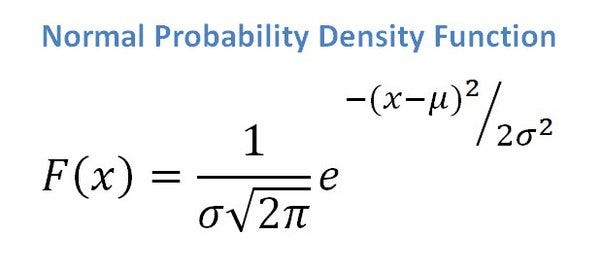

In [ ]:
def gaussian_pdf(x, mu, var):
    return (1.0 / np.sqrt(2 * np.pi * var)) * np.exp(-((x - mu) ** 2) / (2 * var))

**Step 4 — Initialize.** EM needs a starting guess. We split the data at
the 25th and 75th percentile as rough starting means, and start both clusters
with the same variance as the whole dataset and equal weight (50/50). This is
iteration 0 in our tracking table, before any learning happens.

In [ ]:
mu1, mu2 = np.percentile(heights, 25), np.percentile(heights, 75)
var1, var2 = heights.var(), heights.var()
pi1, pi2 = 0.5, 0.5

print(f"init -> mu1={mu1:.2f} mu2={mu2:.2f} var1={var1:.2f} var2={var2:.2f} pi1={pi1} pi2={pi2}")

init -> mu1=64.50 mu2=70.00 var1=12.72 var2=12.72 pi1=0.5 pi2=0.5


**E-step.** For every point, ask "how responsible is cluster 1 vs cluster 2
for this point?" We weigh each cluster's density by its mixing weight $\pi_k$
and normalize so the two responsibilities add up to 1. This is just Bayes'
rule applied to the mixture.

In [ ]:
def e_step(x, mu1, var1, pi1, mu2, var2, pi2):
    w1 = pi1 * gaussian_pdf(x, mu1, var1)
    w2 = pi2 * gaussian_pdf(x, mu2, var2)
    r1 = w1 / (w1 + w2)
    r2 = 1 - r1
    return r1, r2

**M-step.** Now that every point has a soft vote (`r1`, `r2`), we recompute
each cluster's mean, variance and weight as a *weighted* average, using those
votes as weights. Points that mostly belong to cluster 1 pull $\mu_1$ harder,
points that lean cluster 2 pull $\mu_2$ harder.

In [ ]:
def m_step(x, r1, r2):
    n1, n2 = r1.sum(), r2.sum()
    mu1 = np.sum(r1 * x) / n1
    mu2 = np.sum(r2 * x) / n2
    var1 = np.sum(r1 * (x - mu1) ** 2) / n1
    var2 = np.sum(r2 * (x - mu2) ** 2) / n2
    pi1, pi2 = n1 / len(x), n2 / len(x)
    return mu1, var1, pi1, mu2, var2, pi2

**Log-likelihood.**

In [ ]:
def log_likelihood(x, mu1, var1, pi1, mu2, var2, pi2):
    mix = pi1 * gaussian_pdf(x, mu1, var1) + pi2 * gaussian_pdf(x, mu2, var2)
    return np.sum(np.log(mix))

**Step 5 — Run EM.** Alternate E-step and M-step until the log-likelihood
stops improving by more than `tol`. We save every iteration's parameters into
`history` so we can print the tracking table the presentation asks for
(iteration 0, 1, 2, ... up to convergence).

In [ ]:
tol = 1e-2 # 1 x 10^-2 = 0.01
max_iter = 200

ll = log_likelihood(heights, mu1, var1, pi1, mu2, var2, pi2)
history = [{"iter": 0, "mu1": mu1, "mu2": mu2, "var1": var1, "var2": var2,
            "pi1": pi1, "pi2": pi2, "loglik": ll}]

for i in range(1, max_iter + 1):
    r1, r2 = e_step(heights, mu1, var1, pi1, mu2, var2, pi2)
    mu1, var1, pi1, mu2, var2, pi2 = m_step(heights, r1, r2)
    ll_new = log_likelihood(heights, mu1, var1, pi1, mu2, var2, pi2)

    history.append({"iter": i, "mu1": mu1, "mu2": mu2, "var1": var1, "var2": var2,
                     "pi1": pi1, "pi2": pi2, "loglik": ll_new})

    if abs(ll_new - ll) < tol:
        print(f"converged after {i} iterations")
        ll = ll_new
        break
    ll = ll_new

# make sure mu1 always refers to the CHILD cluster (the smaller mean)
if mu1 > mu2:
    mu1, mu2 = mu2, mu1
    var1, var2 = var2, var1
    pi1, pi2 = pi2, pi1

hist_df = pd.DataFrame(history)
hist_df

converged after 25 iterations


,iter,mu1,mu2,var1,var2,pi1,pi2,loglik
0,0,64.500000,70.000000,12.724063,12.724063,0.500000,0.500000,-3119.822164
1,1,65.220488,69.205392,9.060266,8.446806,0.501110,0.498890,-3057.913524
2,2,65.160901,69.259995,8.942017,8.104042,0.500471,0.499529,-3056.971877
3,3,65.102053,69.318093,8.735610,7.824349,0.500369,0.499631,-3056.004263
4,4,65.043577,69.377184,8.491984,7.565277,0.500430,0.499570,-3054.975559
5,5,64.985819,69.435618,8.233187,7.313682,0.500495,0.499505,-3053.903706
6,6,64.929489,69.492064,7.970511,7.068187,0.500495,0.499505,-3052.822861
7,7,64.875462,69.545327,7.711648,6.831961,0.500402,0.499598,-3051.775366
8,8,64.824626,69.594342,7.463081,6.609601,0.500203,0.499797,-3050.805306
9,9,64.777758,69.638248,7.230499,6.405618,0.499894,0.500106,-3049.950766


In [ ]:
tracking_table = hist_df.head(3).copy()
tracking_table.columns = ["Iteration", "mu1 (Children)", "mu2 (Parents)",
                           "sigma1^2", "sigma2^2", "pi1", "pi2", "Log-Likelihood"]
tracking_table.round(4)

,Iteration,mu1 (Children),mu2 (Parents),sigma1^2,sigma2^2,pi1,pi2,Log-Likelihood
0,0,64.5000,70.0000,12.7241,12.7241,0.5000,0.5000,-3119.8222
1,1,65.2205,69.2054,9.0603,8.4468,0.5011,0.4989,-3057.9135
2,2,65.1609,69.2600,8.9420,8.1040,0.5005,0.4995,-3056.9719


In [ ]:
print("EM recovered      -> child mean {:.2f}, father mean {:.2f}".format(mu1, mu2))
print("True group means  -> child mean {:.2f}, father mean {:.2f}".format(children.mean(), fathers.mean()))

EM recovered      -> child mean 64.50, father mean 69.79
True group means  -> child mean 66.75, father mean 69.32


## Visualising two gaussin curves

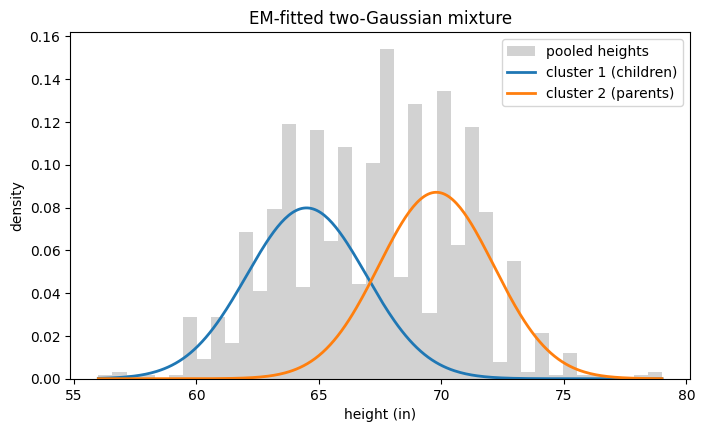

In [ ]:
x_range = np.linspace(heights.min(), heights.max(), 300)
curve1 = pi1 * gaussian_pdf(x_range, mu1, var1)
curve2 = pi2 * gaussian_pdf(x_range, mu2, var2)

plt.figure(figsize=(8, 4.5))
plt.hist(heights, bins=40, density=True, alpha=0.35, color="gray", label="pooled heights")
plt.plot(x_range, curve1, label="cluster 1 (children)", linewidth=2)
plt.plot(x_range, curve2, label="cluster 2 (parents)", linewidth=2)
plt.xlabel("height (in)")
plt.ylabel("density")
plt.title("EM-fitted two-Gaussian mixture")
plt.legend()
plt.show()

In [ ]:
def classify_height(x):
    r_child, r_parent = e_step(np.array([x]), mu1, var1, pi1, mu2, var2, pi2)
    print(f"height = {x} in")
    print(f"  P(Child)  = {r_child[0]:.4f}")
    print(f"  P(Parent) = {r_parent[0]:.4f}")
    return r_child[0], r_parent[0]

classify_height(73)

height = 73 in
  P(Child)  = 0.0053
  P(Parent) = 0.9947


(np.float64(0.005274609720951991), np.float64(0.994725390279048))

In [ ]:
global_mean = heights.mean()
naive_pred = np.where(heights <= global_mean, 0, 1)
naive_acc = (naive_pred == true_group).mean()

r_child_all, r_parent_all = e_step(heights, mu1, var1, pi1, mu2, var2, pi2)
em_pred = np.where(r_child_all >= r_parent_all, 0, 1)
em_acc = (em_pred == true_group).mean()

print(f"naive mean-split accuracy: {naive_acc:.3f}")
print(f"EM (hard assignment) accuracy: {em_acc:.3f}")
print(f"naive pile means: {heights[naive_pred==0].mean():.2f} / {heights[naive_pred==1].mean():.2f}")

naive mean-split accuracy: 0.608
EM (hard assignment) accuracy: 0.605
naive pile means: 64.26 / 70.21


# Part 2: Bayesian Probability

In [ ]:
import pandas as pd
from google.colab import files

df = pd.read_csv("/content/IMDB Dataset.csv")

In [ ]:
df.head()
print(f"Dataset loaded successfully: {df.shape[0]} reviews")

Dataset loaded successfully: 50000 reviews


**Data Cleaning**

In [ ]:
def clean_text(text):
    text = str(text).lower()
    return text

df['review_clean'] = df['review'].apply(clean_text)

**Prior Probability**

In [ ]:
total_reviews = len(df)
positive_reviews = len(df[df['sentiment'] == 'positive'])
prior_positive = positive_reviews / total_reviews

print(f"\nPrior P(Positive) = {prior_positive:.4f}")


Prior P(Positive) = 0.5000


**Keywords**

In [ ]:
keywords = [
    "excellent",
    "amazing",
    "wonderful",
    "masterpiece",
    "worst",
    "terrible",
    "awful",
    "boring"
]

In [ ]:
positive_keywords = ["excellent", "amazing", "wonderful", "masterpiece"]
negative_keywords = ["worst", "terrible", "awful", "boring"]

if word in positive_keywords:
    keyword_type = "Positive"
else:
    keyword_type = "Negative"

**Bayes Theorem Calculation**

In [ ]:
results = []

for word in keywords:
    contains_word = df['review_clean'].str.contains(r'\b' + word + r'\b', regex=True)

    total_with_word = contains_word.sum()
    positive_with_word = len(df[(df['sentiment'] == 'positive') & contains_word])

    likelihood = positive_with_word / positive_reviews if positive_reviews > 0 else 0
    marginal = total_with_word / total_reviews if total_reviews > 0 else 0
    posterior = (likelihood * prior_positive) / marginal if marginal > 0 else prior_positive

    results.append({
    "Keyword": word,
    "Keyword Type": keyword_type,
    "Prior P(Positive)": round(prior_positive, 4),
    "Likelihood P(Keyword|Positive)": round(likelihood, 4),
    "Marginal P(Keyword)": round(marginal, 4),
    "Posterior P(Positive|Keyword)": round(posterior, 4),
    "Occurrences": total_with_word
})

**Final Results**

In [ ]:
result_df = pd.DataFrame(results)
print("\nBAYES THEOREM RESULTS")
print("=" * 75)
print(result_df.to_string(index=False))


BAYES THEOREM RESULTS
    Keyword Keyword Type  Prior P(Positive)  Likelihood P(Keyword|Positive)  Marginal P(Keyword)  Posterior P(Positive|Keyword)  Occurrences
  excellent     Positive                0.5                          0.1147               0.0710                         0.8074         3552
    amazing     Positive                0.5                          0.0672               0.0432                         0.7780         2158
  wonderful     Positive                0.5                          0.0903               0.0556                         0.8122         2780
masterpiece     Positive                0.5                          0.0351               0.0241                         0.7274         1207
      worst     Positive                0.5                          0.0164               0.0887                         0.0927         4434
   terrible     Positive                0.5                          0.0153               0.0540                         0.1418    

**save the result**

In [ ]:
result_df.to_csv('/content/bayes_results.csv', index=False)
print("\nResults saved successfully as 'bayes_results.csv'")


Results saved successfully as 'bayes_results.csv'


# Part 4: Gradient Descent in Code

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

In [ ]:
X = np.array([
    [1, 3],
    [4, 10]
], dtype=float)

y = np.array([5, 6], dtype=float)

# Initial parameters
m = np.array([-1, 2], dtype=float)
b = 1.0

learning_rate = 0.1
num_iterations = 4

In [ ]:
def predict(X, m, b):
    return X @ m + b

In [ ]:
def mse_equation(params, X, y):
    """
    params = [m1, m2, b]
    """
    m = np.array([params[0], params[1]])
    b = params[2]

    y_pred = predict(X, m, b)
    error = y_pred - y

    return np.mean(error ** 2)

In [ ]:
def compute_gradient_with_scipy(params, X, y):
    epsilon = np.sqrt(np.finfo(float).eps)

    gradient = approx_fprime(
        params,
        mse_equation,
        epsilon,
        X,
        y
    )

    return gradient

In [ ]:
history = []

params = np.array([m[0], m[1], b], dtype=float)

for iteration in range(num_iterations + 1):
    current_m = np.array([params[0], params[1]])
    current_b = params[2]

    y_pred = predict(X, current_m, current_b)
    error = y_pred - y
    mse = mse_equation(params, X, y)

    gradient = compute_gradient_with_scipy(params, X, y)

    history.append({
        "Iteration": iteration,
        "m1": current_m[0],
        "m2": current_m[1],
        "b": current_b,
        "Prediction 1": y_pred[0],
        "Prediction 2": y_pred[1],
        "Error 1": error[0],
        "Error 2": error[1],
        "MSE": mse,
        "Gradient m1": gradient[0],
        "Gradient m2": gradient[1],
        "Gradient b": gradient[2]
    })

    print(f"\nIteration {iteration}")
    print("m:", current_m)
    print("b:", current_b)
    print("Predictions:", y_pred)
    print("Errors:", error)
    print("MSE:", mse)
    print("Gradient from SciPy:", gradient)

    if iteration == num_iterations:
        break

    params = params - learning_rate * gradient


Iteration 0
m: [-1.  2.]
b: 1.0
Predictions: [ 6. 17.]
Errors: [ 1. 11.]
MSE: 61.0
Gradient from SciPy: [ 45.         113.00000095  12.        ]

Iteration 1
m: [-5.5       -9.3000001]
b: -0.20000000000000018
Predictions: [ -33.60000029 -115.20000095]
Errors: [ -38.60000029 -121.20000095]
MSE: 8089.700126628877
Gradient from SciPy: [ -523.40002441 -1327.79998779  -159.80004883]

Iteration 2
m: [ 46.84000244 123.47999868]
b: 15.780004882812502
Predictions: [ 433.06000338 1437.94000149]
Errors: [ 428.06000338 1431.94000149]
MSE: 1116843.7671754765
Gradient from SciPy: [ 6155.8125   15603.578125  1860.      ]

Iteration 3
m: [ -568.74124756 -1436.87781382]
b: -170.2199951171875
Predictions: [ -5049.59468412 -16813.96312351]
Errors: [ -5054.59468412 -16819.96312351]
MSE: 154230043.44854355
Gradient from SciPy: [ -72334. -183360.  -21874.]

Iteration 4
m: [ 6664.65875244 16899.12218618]
b: 2017.1800048828127
Predictions: [ 59379.20531588 197667.03687649]
Errors: [ 59374.20531588 197661.036

In [ ]:
results_df = pd.DataFrame(history)
results_df

,Iteration,m1,m2,b,Prediction 1,Prediction 2,Error 1,Error 2,MSE,Gradient m1,Gradient m2,Gradient b
0,0,-1.000000,2.000000,1.000000,6.000000,17.000000,1.000000,11.000000,6.100000e+01,45.000000,1.130000e+02,12.000000
1,1,-5.500000,-9.300000,-0.200000,-33.600000,-115.200001,-38.600000,-121.200001,8.089700e+03,-523.400024,-1.327800e+03,-159.800049
2,2,46.840002,123.479999,15.780005,433.060003,1437.940001,428.060003,1431.940001,1.116844e+06,6155.812500,1.560358e+04,1860.000000
3,3,-568.741248,-1436.877814,-170.219995,-5049.594684,-16813.963124,-5054.594684,-16819.963124,1.542300e+08,-72334.000000,-1.833600e+05,-21874.000000
4,4,6664.658752,16899.122186,2017.180005,59379.205316,197667.036876,59374.205316,197661.036876,2.129759e+10,849920.000000,2.154752e+06,257024.000000


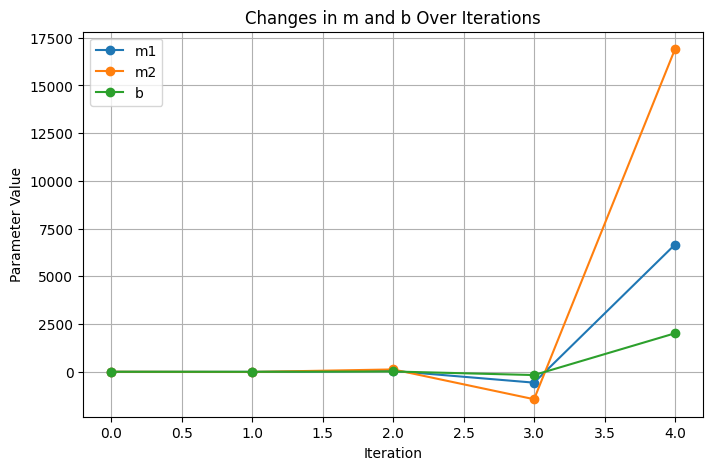

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(results_df["Iteration"], results_df["m1"], marker="o", label="m1")
plt.plot(results_df["Iteration"], results_df["m2"], marker="o", label="m2")
plt.plot(results_df["Iteration"], results_df["b"], marker="o", label="b")

plt.xlabel("Iteration")
plt.ylabel("Parameter Value")
plt.title("Changes in m and b Over Iterations")
plt.legend()
plt.grid(True)
plt.show()

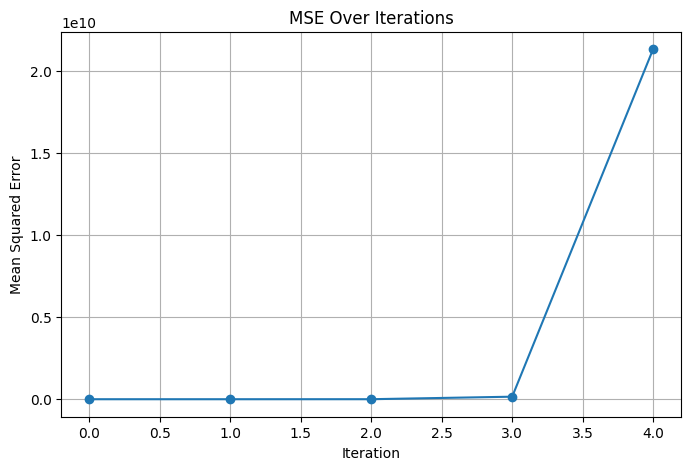

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(results_df["Iteration"], results_df["MSE"], marker="o")

plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("MSE Over Iterations")
plt.grid(True)
plt.show()